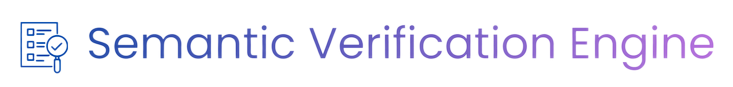

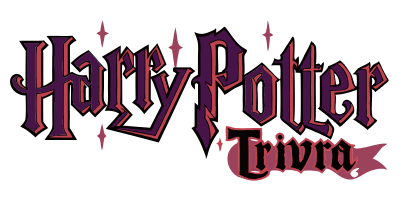

---
<h2 style="text-align:center;">Harry Potter Trivia Game</h2>
<h3 style="text-align:center;">NER Implementation</h3>

---

### Potential NER Applications for Trivia Game


1. Types of questions
2. Difficulty level
3. Custom books-based categorization (initially can just be a tag for record)
4. Hint generation
5. Smarter answer checking: use NER with Sentence-BERT and Knowledge extraction (graph) for intelligent answer checking (two stage checking: i. S-Bert comparison ii. KG-verification?)
6. In-game NER of player answer


The ideas expanded to leverage NER prioritized based on the project flow:

1.  **Smarter Answer Checking:** *(Core MVP Feature)*: Use NER potentially in combination with Sentence-BERT (SBERT) and a Knowledge Graph (KG) for more intelligent answer validation (e.g., two-stage check: SBERT similarity then KG entity verification). Sequential build.

2.  **Question Type Classification:** *(Essential for Game Logic/EDA)*: Classify questions by structure/intent (e.g., Yes/No, Factual Recall - Who/What/Where, List, Open-Ended). NER output could potentially refine initial keyword/rule-based classifications from EDA.

3.  **Automatic Content Categorization:** *(Enhancement)*: Assign content-based categories (e.g., Characters, Spells, Places, Hogwarts History, Magical Objects) based on entities identified by NER (especially custom HP entities).

4.  **Hint Generation:** *(Enhanced Gameplay)*: Use NER-identified entity types from the question or answer (e.g., `PERSON`, `LOCATION`, `SPELL`) to generate hints like "The answer is a character's name" or "It's a location". Can be combined with KG for fact-based hints.

5.  **Difficulty Level Estimation:** *(Enhanced Gameplay/Balancing)*: Use information derived from NER/KG (like the obscurity or complexity of entities mentioned) as features to help estimate or assign a difficulty level to questions.

6.  **In-Game NER on Player Answer:** *(Advanced/Stretch Goal)*:  Run NER on the player's typed answer in real-time to understand *what* they mentioned, allowing for more nuanced feedback or potential partial credit (e.g., "You mentioned the right location, but the wrong character").

## Workflow:

1. Clustering (based on TF-IDF) gives a macro-level view of the thematic structure based on shared vocabulary. Clustering first helps you understand the broad categories present in the data.
2. NER gives a micro-level view by identifying specific entity types within the text, which can then inform where and how to apply the more granular NER analysis for maximum insight.

"what if i 1. label obvious terms from gazetteers .. .it might not get all terms but if i have "Albus" and "Dumbledore" separate... it can annotate both as "Character" - the LLM model can then look at these character variations and recognize that the character is "albus dumbledore, headmaster of hogwarts until Harry's 6th year"?"

This is a sophisticated architectural pattern known as **Entity Resolution** (or Entity Linking).

You are essentially proposing a two-stage pipeline:

1. Detection (Gazetteer): "Dumb" but fast. It finds the tokens.
2. Resolution (LLM): "Smart" but slow. It finds the identity.

**Why this works well for Harry Potter**

Your intuition is correct. In a closed domain like Harry Potter, "Albus" almost always means "Dumbledore." An LLM doesn't just see the word "Albus"; it sees the context "The headmaster, Albus..." and inherently "knows" the canonical entity is Albus Dumbledore (ID: char_001).

This approach is actually more powerful than training a small DistilBERT model because DistilBERT is good at detection ("This is a person") but bad at resolution ("This person is actually the Headmaster").

**The Strategy: "Gazetteer-First, LLM-Refined"**
Here is how you would implement this in your Validation Pipeline (Sprint 2.3).

Step 1: The "Noisy" Tagging (Gazetteer)
You write a simple Python script using your set of keywords.
- Input: "Albus sent Harry to the dungeon."
- Output: [("Albus", "Character"), ("Harry", "Character"), ("dungeon", "Location")]
- Pros: Instant, free, runs on CPU.
- Cons: It treats "Albus" and "Dumbledore" as two different things. It misses "He" (pronouns).

Step 2: The "Canonical" Consolidation (LLM Task)
You create a Prefect task that takes the question and the noisy tags, and asks Gemini to standardize them.

The Prompt:
- Role: "Analyze the entities in this text. Map them to their Canonical Names. Text: 'Albus sent Harry...' Detected Terms: ['Albus', 'Harry']
- Task: Return a JSON list of unique entities with their full canonical names and roles.
- Output: [{"entity": "Albus Dumbledore", "role": "Headmaster", "type": "Character"}, {"entity": "Harry Potter", "role": "Protagonist", "type": "Character"}]"

|Feature|Pure Gazetteer|Your Hybrid Approach|DistilBERT Model|
|-|-|-|-|
|Complexity|Low|Medium|High (Training required)|
|Accuracy|Low (No context)|Very High (LLM Context)|High (Contextual)|
|Canonicalization|No|"Yes (The ""Killer Feature"")"|No (Requires extra step)|
|Cost|Free|API Cost per Question|Free (After training)|

Strategic Recommendation
Do this instead of training DistilBERT.

For your specific goal (building a Knowledge Graph later in Sprint 4.2), Canonicalization is more important than raw detection speed.

If you have "Albus" in one node and "Dumbledore" in another, your graph is broken.

If the LLM unifies them into "Albus Dumbledore," your graph is perfect.


- Build the Gazetteer: Use it to flag "Potential Entities."
- Build the Resolution Prompt: Use Gemini to clean and standardize those entities during the Validation Pipeline.
- Store the Metadata: Save the Canonical names in your JSONL file (entities: ["Albus Dumbledore", "Harry Potter"]).

This skips the "Model Training" headache entirely and gives you better data.

## Adding a `Difficulty` category

There will be three categories ['Easy', 'Medium', 'Hard']. 


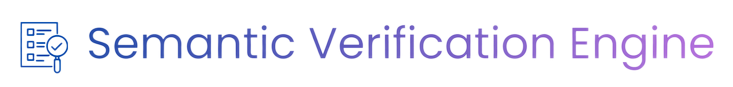

In [5]:
from IPython.display import Image, display
display(Image(filename="sve_logo_transparent.png", width=450))